In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob
from math import log2
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.cm.get_cmap('RdYlBu')


pd.set_option('display.max_rows', 200)

/tmp/ipykernel_276576/4001252914.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('RdYlBu')


### Load Recast Data

In [2]:
# inputFiles = ['/home/ramos/MG5/dmsimpt_pptoxdxd_no_onshell_match/Events/run_08/combined_nocut_cms_exo_20_004.pcl']

# dfs = [pd.read_pickle(i) for i in inputFiles]
# recastData = pd.concat(dfs, ignore_index=True)

In [ ]:
df1 = pd.read_pickle('/home/ramos/MG5/dmsimpt_pptoxdxd_no_onshell_match/Events/run_08/combined_nocut_cms_exo_20_004.pcl')
df1['version'] = '0j+1j'

df2 = pd.read_pickle('../scanResults_S3D_uR_CMS-BPs_v2_1j_nocut.pcl')
df2['version'] = '1j'

recastData = pd.concat([df1, df2], ignore_index=True)

In [4]:
cmsData = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [5]:
recastData.columns

Index(['Data-takingperiod', 'Luminosity (1/fb)', 'bin_250.0_280.0',
       'bin_250.0_280.0_ErrorPlus', 'bin_250.0_280.0_ErrorMinus',
       'bin_280.0_310.0', 'bin_280.0_310.0_ErrorPlus',
       'bin_280.0_310.0_ErrorMinus', 'bin_310.0_340.0',
       'bin_310.0_340.0_ErrorPlus', 'bin_310.0_340.0_ErrorMinus',
       'bin_340.0_370.0', 'bin_340.0_370.0_ErrorPlus',
       'bin_340.0_370.0_ErrorMinus', 'bin_370.0_400.0',
       'bin_370.0_400.0_ErrorPlus', 'bin_370.0_400.0_ErrorMinus',
       'bin_400.0_430.0', 'bin_400.0_430.0_ErrorPlus',
       'bin_400.0_430.0_ErrorMinus', 'bin_430.0_470.0',
       'bin_430.0_470.0_ErrorPlus', 'bin_430.0_470.0_ErrorMinus',
       'bin_470.0_510.0', 'bin_470.0_510.0_ErrorPlus',
       'bin_470.0_510.0_ErrorMinus', 'bin_510.0_550.0',
       'bin_510.0_550.0_ErrorPlus', 'bin_510.0_550.0_ErrorMinus',
       'bin_550.0_590.0', 'bin_550.0_590.0_ErrorPlus',
       'bin_550.0_590.0_ErrorMinus', 'bin_590.0_640.0',
       'bin_590.0_640.0_ErrorPlus', 'bin_590.0_

### Get all model points

In [6]:
models = []
mCols = ['Mode', '$m_{med}$', '$m_{DM}$', '$\lambda$']
for row in recastData[mCols].values:
    m = dict(zip(mCols, row.tolist()))
    if m not in models:
        models.append(m)

print('%i models loaded.' %len(models))

48 models loaded.


### Get models parameters

In [7]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Mode': 'DM+QCDjets', '$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0], '$\\lambda$': 1.0}
Mode = DM+QCDjets
$\lambda$ = 1.0


### Filter parameters

In [8]:
paramFilter = {
    'Mode' : 'DM+QCDjets',
    '$m_{med}$' : 300.,
    '$m_{DM}$' : 200.,
    '$\lambda$' : 1.,
    'Data-takingperiod' : 2017
}

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in paramFilter.items()])
dfModel = recastData.loc[(recastData[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]
dfCMS = cmsData.loc[(cmsData[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]

In [9]:
dfModel.T

,1,13
Data-takingperiod,2017,2017
Luminosity (1/fb),41.5,41.5
bin_250.0_280.0,7482.226985,7274.080047
bin_250.0_280.0_ErrorPlus,394.168807,430.879315
bin_250.0_280.0_ErrorMinus,394.168807,430.879315
bin_280.0_310.0,4918.744411,5793.740949
bin_280.0_310.0_ErrorPlus,318.92545,384.544093
bin_280.0_310.0_ErrorMinus,318.92545,384.544093
bin_310.0_340.0,3586.393021,4109.217149
bin_310.0_340.0_ErrorPlus,272.741237,323.85168


In [10]:
dfCMS.T

,172
$m_{med}$,300.0
$m_{DM}$,200.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.51669
$p_{T}^{miss}>250$GeV,0.096462
$p_{T}^{miss}$qualityfilters,0.096312
Electronveto,0.09546


The efficiency for the $i$-th bin, $\epsilon_{i}$, is given by:

$$ \epsilon_{i} = \frac{n^{i}_{s}}{\sigma_{T}\mathcal{L}},   $$
where $n^{i}_{s}$ is the number of events in the correspondent bin, $\sigma_{T}$ is the total cross-section, and $\mathcal{L}$ is the integrated luminosity.  

### Plot Efficiencies

In [11]:
# get efficiencies
effcols = ['Fullsample', 'Triggeremulation', '$p_{T}^{miss}>250$GeV', 
           'Electronveto', 'Muonveto', 'Tauveto',
           'Bjetveto', 'Photonveto', '$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad',
           'LeadingAK4jet$p_{T}>100$GeV', 'LeadingAK4jet$\eta<2.4$',
           'HCALmitigation(jets)', 'HCALmitigation($\phi^{miss}$)']
cmsEffs = dfCMS[effcols]
modelEffs = dfModel[effcols+['version']]

In [12]:
# get uncetainties (model only)
nFullsample = np.array(dfModel[[c for c in dfModel.columns if ("bin_" in c and not 'Error' in c)]].sum(axis=1).tolist())/np.array(dfModel['HCALmitigation($\\phi^{miss}$)'])

In [13]:
nFullsample

array([406452.33480079, 386368.50437138])

In [14]:
nevts_list = []
for n in nFullsample:
    ne = n*modelEffs[effcols].T
    ne = ne[1].tolist()
    nevts_list.append(np.array(ne))

In [15]:
effErr_list = []
for i, nevts in enumerate(nevts_list):
    nerr = np.sqrt(nevts)
    eff = np.array(modelEffs[effcols].T[1].tolist())
    effErr = (nerr / nevts) * eff
    effErr_list.append(np.array(effErr))

In [16]:
dfErr = pd.DataFrame(effErr_list, columns=effcols)

In [17]:
dfErr['version'] = modelEffs['version'].tolist()

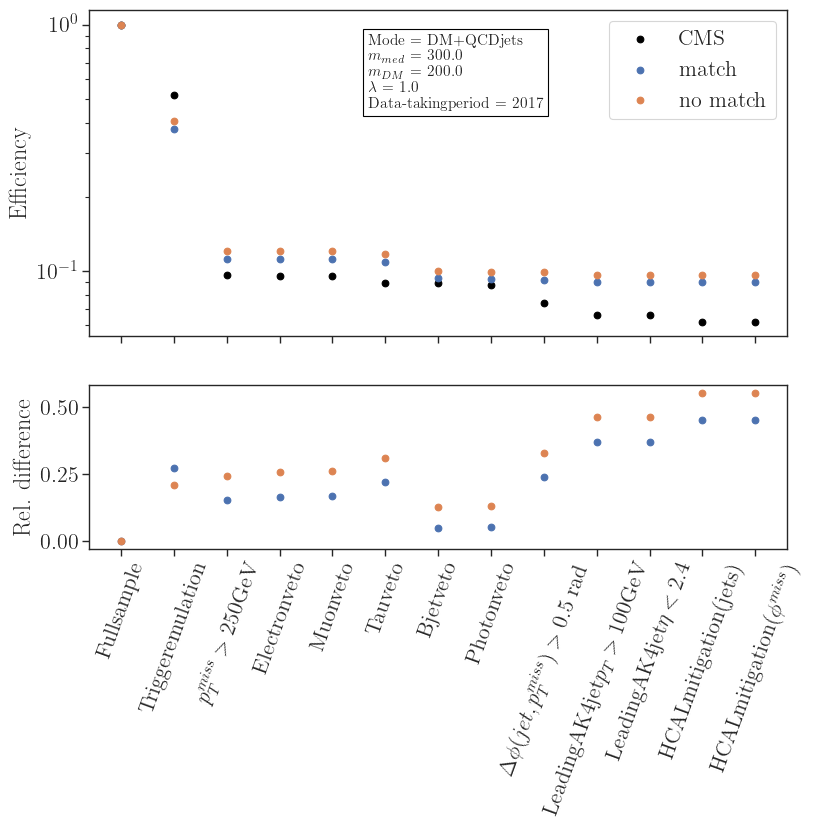

In [18]:
fig, ax = plt.subplots(2, sharex=True, gridspec_kw= {'height_ratios':[2,1]},figsize=(9,7))

# first plot: efficiencies
xaxisLabel = cmsEffs.columns.tolist()

ax[0].scatter(x=xaxisLabel, y=cmsEffs, color='black', label='CMS')
for label in modelEffs['version']:
    singleEff = modelEffs[modelEffs['version']==label]
    singleEff = singleEff[effcols]
    ax[0].scatter(x=xaxisLabel, y=singleEff, label=label)

ax[0].legend()
ax[0].set_ylabel(r'Efficiency')
ax[0].set_yscale('log')
ax[0].text(.4, 2.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)

# second plot: relative differences
for label in modelEffs['version']:
    singleEff = modelEffs[modelEffs['version']==label]
    singleEff = singleEff[effcols]
    relDiff = np.abs(np.array(singleEff) - np.array(cmsEffs))/np.array(cmsEffs)
    ax[1].scatter(x=xaxisLabel, y=relDiff, label=label)

ax[1].set_ylabel(r'Rel. difference')

plt.xticks(rotation=70)

plt.show()

### Plot Efficiencies

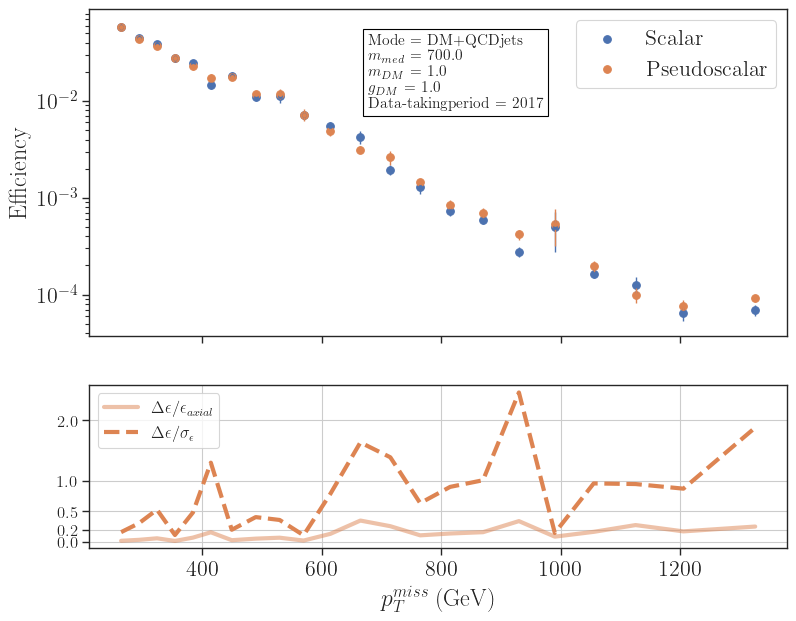

In [ ]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2, 1]},figsize=(9,7))


data = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])

colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax[0].scatter(x=binCenter, y=eff, s=30, color=colors[label], label=label)
    ax[0].errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

# diff = np.abs(data.Axial - data.Vector)

diff = np.abs(data.Pseudoscalar - data.Scalar)

# relDiff = diff/data.Axial
relDiff = diff/data.Pseudoscalar

relDiff = relDiff.replace(np.nan, 0)

# diffError = np.array(diff)/np.sqrt(dataError.Axial**2 + dataError.Vector**2)
# diffError = diffError.replace(np.nan, 0)
diffError = np.array(diff)/np.sqrt(dataError.Pseudoscalar**2 + dataError.Scalar**2)
diffError = diffError.replace(np.nan, 0)

label1 = r'$\Delta \epsilon / \epsilon_{axial}$'
# label1 = r'$\frac{\mbox{Axial-Vector}}{\mbox{Axial}}$'
label2 = r'$\Delta \epsilon / \sigma_{\epsilon}$'

ax[1].plot(binCenter, relDiff, color=colors[label], linewidth=3., label=label1, alpha=.5)
ax[1].plot(binCenter, diffError, color=colors[label], linewidth=3., linestyle='--', 
           label=label2)

    
ax[0].set_yscale('log')
ax[0].text(.4, 2.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax[0].set_ylabel('Efficiency')
ax[0].legend()

# ax[1].set_ylim(0., 2.)
ax[1].legend(fontsize='12')
ax[1].grid(True)
ax[1].set_yticks([0., 0.2, 0.5, 1., 2.])
ax[1].tick_params(axis='y', labelsize='12')
ax[1].set_xlabel(r'$p_{T}^{miss}$ (GeV)')
# ax[1].set_ylabel('Relative diff.')

plt.show()

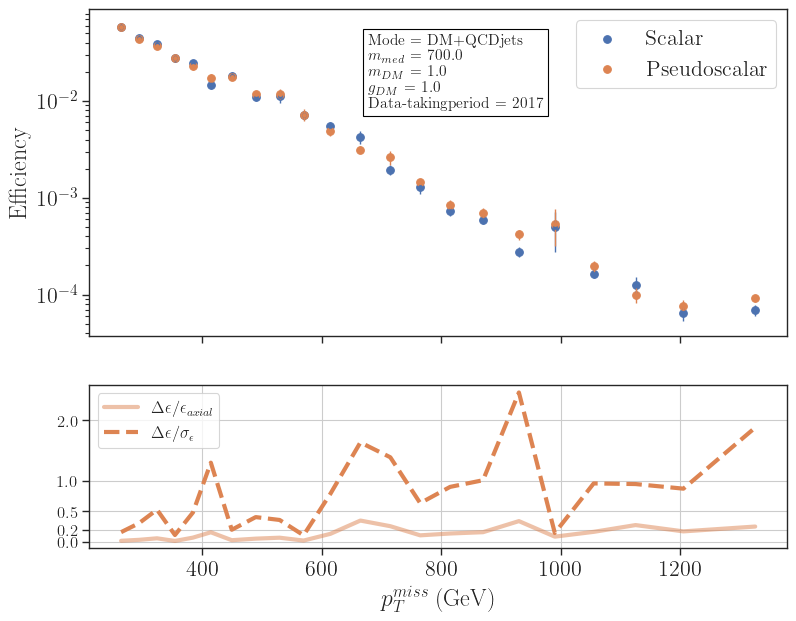

In [10]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2, 1]},figsize=(9,7))

# data = pd.DataFrame(columns=['Axial', 'Vector'])
# dataError = pd.DataFrame(columns=['Axial', 'Vector'])

data = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])

colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax[0].scatter(x=binCenter, y=eff, s=30, color=colors[label], label=label)
    ax[0].errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

# diff = np.abs(data.Axial - data.Vector)

diff = np.abs(data.Pseudoscalar - data.Scalar)

# relDiff = diff/data.Axial
relDiff = diff/data.Pseudoscalar

relDiff = relDiff.replace(np.nan, 0)

# diffError = np.array(diff)/np.sqrt(dataError.Axial**2 + dataError.Vector**2)
# diffError = diffError.replace(np.nan, 0)
diffError = np.array(diff)/np.sqrt(dataError.Pseudoscalar**2 + dataError.Scalar**2)
diffError = diffError.replace(np.nan, 0)

label1 = r'$\Delta \epsilon / \epsilon_{axial}$'
# label1 = r'$\frac{\mbox{Axial-Vector}}{\mbox{Axial}}$'
label2 = r'$\Delta \epsilon / \sigma_{\epsilon}$'

ax[1].plot(binCenter, relDiff, color=colors[label], linewidth=3., label=label1, alpha=.5)
ax[1].plot(binCenter, diffError, color=colors[label], linewidth=3., linestyle='--', 
           label=label2)

    
ax[0].set_yscale('log')
ax[0].text(.4, 2.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax[0].set_ylabel('Efficiency')
ax[0].legend()

# ax[1].set_ylim(0., 2.)
ax[1].legend(fontsize='12')
ax[1].grid(True)
ax[1].set_yticks([0., 0.2, 0.5, 1., 2.])
ax[1].tick_params(axis='y', labelsize='12')
ax[1].set_xlabel(r'$p_{T}^{miss}$ (GeV)')
# ax[1].set_ylabel('Relative diff.')

plt.show()